In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
params = {
    "RS": (0.02, 0.2, -65, 2),
    "IB": (0.02, 0.2, -55, 4),
    "CH": (0.02, 0.2, -50, 2),
    "FS": (0.1, 0.2, -65, 2),
    "TC": (0.02, 0.25, -65, 0.05),
    "RZ": (0.1, 0.26, -65, 0.05),
    "LTS": (0.02, 0.25, -65, 2)
}

In [ ]:
def I_input(t):
    if 10 < t < 40:
        return 10
    return 0

In [5]:
def izhikevich_model(a, b, c, d, time, step):
    v = -65
    u = b * v
    v_vector = []
    spike_times = []
    spike_values = []

    for t in time:
        I = I_input(t)
        dv = 0.04 * v**2 + 5 * v + 140 - u + I
        du = a * (b * v - u)

        v += step * dv
        u += step * du

        if v >= 30:
            spike_times.append(t)
            spike_values.append(v)
            v = c
            u += d

        v_vector.append(v)

    return np.array(v_vector), np.array(spike_times), np.array(spike_values)

In [6]:
def layer(params, time, step):
    outputs = []
    for name, (a, b, c, d) in params.items():
        v, spike_t, spike_v = izhikevich_model(a, b, c, d, time, step)
        outputs.append((name, v, spike_t, spike_v))
    return outputs

step = 0.01
t_start = 0
t_end = 100
time = np.arange(t_start, t_end, step)

outputs = layer(params, time, step)

TypeError: type numpy.ndarray doesn't define __round__ method

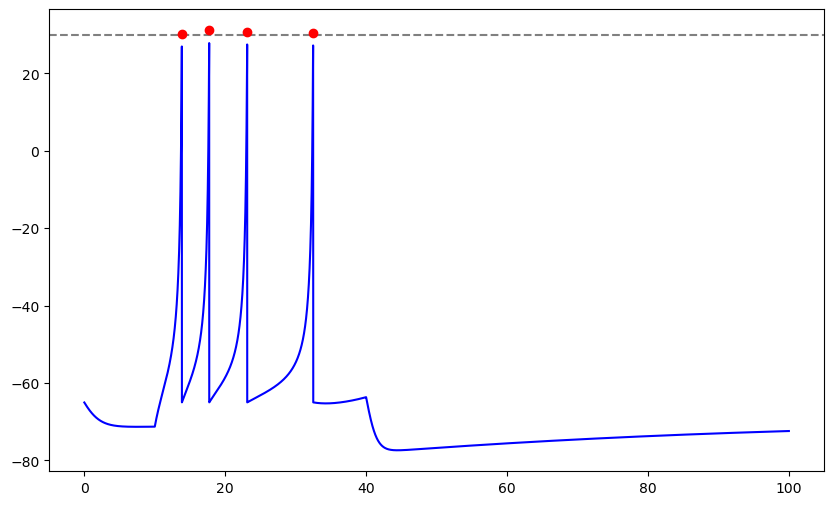

In [10]:
for name, v, spike_t, spike_v in outputs:
    plt.figure(figsize=(10, 6))
    plt.plot(time, v, label="Membrane Potential (mV)", color="blue")

    plt.scatter(spike_t, spike_v, color="red", label="Spikes", zorder=5)

    plt.axhline(30, linestyle="--", color="gray", label="Threshold (30 mV)")

    max_spike_value = np.max(spike_v) if len(spike_v) > 0 else 0

    plt.text(0.02, 0.95,
             f"Final v: {v[-1]:.2f} mV\n"
             f"Max Spike: {round(max_spike_value,2)} mV\n"
             f"Spike Count: {len(spike_t)}\n"
             f"Spike Times: {spike_t[:5]}{'...' if len(spike_t) > 5 else ''}\n"
             f"Spike Values: {round(spike_v[:5],2)}{'...' if len(spike_v) > 5 else ''}",
             transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8),
             fontsize=9,
             verticalalignment='top')

    plt.title(f"Izhikevich Neuron: {name}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane Potential (mV)")
    plt.legend()
    plt.grid(True)
    plt.show()